In [ ]:
!kaggle datasets download vrajesh0sharma7/used-car-price-prediction

Dataset URL: https://www.kaggle.com/datasets/vrajesh0sharma7/used-car-price-prediction
License(s): CC0-1.0
100% 374k/374k [00:00<00:00, 65.9MB/s]



In [ ]:
!unzip used-car-price-prediction.zip

Archive:  used-car-price-prediction.zip
  inflating: Used_Car_Price_Prediction.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
car_df = pd.read_csv('Used_Car_Price_Prediction.csv')
car_df.head(15)

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,assured_buy,registered_city,registered_state,is_hot,rto,source,make,model,car_availability,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,True,delhi,delhi,True,dl6c,inperson_sale,maruti,swift,in_stock,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,True,noida,uttar pradesh,True,up16,inperson_sale,maruti,alto 800,in_stock,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,True,agra,uttar pradesh,True,up80,inperson_sale,hyundai,grand i10,in_stock,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,True,delhi,delhi,True,dl1c,inperson_sale,maruti,swift,in_stock,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,False,new delhi,delhi,True,dl12,inperson_sale,hyundai,grand i10,in_stock,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
5,maruti alto k10,2018,petrol,23534,335299,noida,1055,hatchback,NaN,vxi (o) amt,True,delhi,delhi,True,dl2c,inperson_sale,maruti,alto k10,in_stock,1,343212,439056.0,great,2021-04-13T05:55:16.99,True,7788,50295,False,False
6,maruti ritz,2012,diesel,41213,281999,noida,909,hatchback,manual,vdi,True,delhi,delhi,True,dl12,inperson_sale,maruti,ritz,in_stock,1,201200,NaN,great,2020-12-29T07:26:25.321,True,6550,42300,False,False
7,hyundai i20,2012,petrol,38328,321499,noida,2760,hatchback,manual,asta 1.2,True,noida,uttar pradesh,True,up16,inperson_sale,hyundai,i20,in_stock,3,319200,410764.0,great,2021-02-25T15:47:30.3,True,7468,48225,False,False
8,hyundai elite i20,2014,diesel,56402,456199,noida,2475,hatchback,manual,magna 1.4 crdi,True,noida,uttar pradesh,True,up16,inperson_sale,hyundai,elite i20,in_stock,1,452023,566123.0,great,2021-03-13T11:57:25.71,True,10596,68430,False,False
9,renault kwid,2018,petrol,32703,281299,noida,2497,hatchback,manual,rxl,True,noida,uttar pradesh,True,up16,inperson_sale,renault,kwid,in_transit,1,264597,344127.0,great,2021-03-20T06:52:56.488,True,6534,42195,False,False


In [ ]:
car_df[car_df.duplicated(keep=False)]

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,assured_buy,registered_city,registered_state,is_hot,rto,source,make,model,car_availability,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
2323,mahindra thar,2017,diesel,37134,671399,new delhi,4603,suv,manual,crde 4x4 bs iv,True,new delhi,delhi,True,dl8c,inperson_sale,mahindra,thar,in_stock,1,646565,NaN,great,2021-03-07T10:10:19.937,True,15595,100710,True,False
7399,mahindra thar,2017,diesel,37134,671399,new delhi,4603,suv,manual,crde 4x4 bs iv,True,new delhi,delhi,True,dl8c,inperson_sale,mahindra,thar,in_stock,1,646565,NaN,great,2021-03-07T10:10:19.937,True,15595,100710,True,False


In [ ]:
car_df.shape

(7400, 29)

In [ ]:
car_df.drop_duplicates(inplace=True)

In [ ]:
car_df['body_type'].value_counts()

,count
body_type,
hatchback,4358
sedan,1483
suv,1103
luxury suv,189
luxury sedan,163


In [ ]:
car_df['car_availability'].value_counts()

,count
car_availability,
in_stock,6484
in_transit,225
pickup_pending,45
out_of_stock,25


In [ ]:
car_df['city'].value_counts()

,count
city,
mumbai,1336
bengaluru,1250
new delhi,1152
pune,772
chennai,702
hyderabad,633
ahmedabad,420
gurgaon,351
noida,313


In [ ]:
car_df['source'].value_counts()

,count
source,
inperson_sale,6833
online,397
customer_to_customer,43


In [ ]:
car_df.drop(columns=['car_name','registered_state','original_price','ad_created_on'],inplace=True)

In [ ]:
car_df.shape

(7399, 25)

In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7399 entries, 0 to 7398
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   yr_mfr               7399 non-null   int64 
 1   fuel_type            7399 non-null   object
 2   kms_run              7399 non-null   int64 
 3   sale_price           7399 non-null   int64 
 4   city                 7399 non-null   object
 5   times_viewed         7399 non-null   int64 
 6   body_type            7296 non-null   object
 7   transmission         6843 non-null   object
 8   variant              7399 non-null   object
 9   assured_buy          7399 non-null   bool  
 10  registered_city      7389 non-null   object
 11  is_hot               7399 non-null   bool  
 12  rto                  7399 non-null   object
 13  source               7273 non-null   object
 14  make                 7399 non-null   object
 15  model                7399 non-null   object
 16  car_availab

In [ ]:
car_df.isna().sum()

,0
yr_mfr,0
fuel_type,0
kms_run,0
sale_price,0
city,0
times_viewed,0
body_type,103
transmission,556
variant,0
assured_buy,0


In [ ]:
car_df['body_type'].value_counts()

,count
body_type,
hatchback,4358
sedan,1483
suv,1103
luxury suv,189
luxury sedan,163


In [ ]:
car_df['transmission'].value_counts()

,count
transmission,
manual,6214
automatic,629


In [ ]:
car_df['registered_city'].value_counts()

,count
registered_city,
delhi,963
bengaluru,665
chennai,599
hyderabad,593
pune,581
...,...
veraval,1
hindupur,1
junagadh,1


In [ ]:
car_df['source'].value_counts()

,count
source,
inperson_sale,6833
online,397
customer_to_customer,43


In [ ]:
car_df['car_availability'].value_counts()

,count
car_availability,
in_stock,6484
in_transit,225
pickup_pending,45
out_of_stock,25


In [ ]:
cat = car_df.select_dtypes(include=['object','boolean']).columns

In [ ]:
for col in cat:
   print(f'{col}: {car_df[col].nunique()}')

fuel_type: 5
city: 13
body_type: 5
transmission: 2
variant: 943
assured_buy: 2
registered_city: 243
is_hot: 2
rto: 261
source: 3
make: 27
model: 185
car_availability: 4
car_rating: 4
fitness_certificate: 2
reserved: 2
warranty_avail: 2


In [ ]:
car_df['rto'].value_counts()

,count
rto,
mh12,380
mh02,375
hr26,272
ka03,251
mh04,238
...,...
gj32,1
mh22,1
tn38,1


In [ ]:
car_df.isna().sum()

,0
yr_mfr,0
fuel_type,0
kms_run,0
sale_price,0
city,0
times_viewed,0
body_type,103
transmission,556
variant,0
assured_buy,0


In [ ]:
car_df.drop('rto',axis=1,inplace=True)

In [ ]:
car_df.select_dtypes(include=['object','boolean']).columns

Index(['fuel_type', 'city', 'body_type', 'transmission', 'variant',
       'assured_buy', 'registered_city', 'is_hot', 'source', 'make', 'model',
       'car_availability', 'car_rating', 'fitness_certificate', 'reserved',
       'warranty_avail'],
      dtype='object')

In [ ]:
car_df.select_dtypes(include=['number']).columns

Index(['yr_mfr', 'kms_run', 'sale_price', 'times_viewed', 'total_owners',
       'broker_quote', 'emi_starts_from', 'booking_down_pymnt'],
      dtype='object')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

X = car_df.drop('sale_price',axis=1)
y = car_df['sale_price']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


ord_cat = ['city','variant','registered_city','make','model']
oneh_cat = ['fuel_type','body_type','transmission','assured_buy','is_hot','source',
          'car_availability','car_rating','fitness_certificate','reserved','warranty_avail']
num_col = X_train.select_dtypes(include=['number']).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord_encoder', OrdinalEncoder( handle_unknown='use_encoded_value',unknown_value=-1))
])

oneh_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('oneh_encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False
))
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('ord', ord_pipeline, ord_cat),
    ('oneh', oneh_pipeline, oneh_cat)
])

full_pipeline.fit(X_train)

X_train = full_pipeline.transform(X_train)
X_valid = full_pipeline.transform(X_valid)
X_test = full_pipeline.transform(X_test)


X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

# y_scaler = StandardScaler()
# y_train = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
# y_valid = y_scaler.transform(y_valid.to_numpy().reshape(-1,1))
# y_test = y_scaler.transform(y_test.to_numpy().reshape(-1,1))

y_train = torch.FloatTensor(y_train.to_numpy()).view(-1,1)
y_valid = torch.FloatTensor(y_valid.to_numpy()).view(-1,1)
y_test = torch.FloatTensor(y_test.to_numpy()).view(-1,1)

print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)



torch.Size([4735, 45]) torch.Size([1184, 45]) torch.Size([1480, 45])
torch.Size([4735, 1]) torch.Size([1184, 1]) torch.Size([1480, 1])


In [ ]:
%pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.6 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

device

device(type='cpu')

In [ ]:
def train(model, criterion, optimizer, metric, train_loader, valid_loader, n_epochs,clip_grad=False):
    history = {
        'loss': [],
        'train_metric': [],
        'valid_metric': []
    }
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            y_pred = model(X_batch)
            loss = criterion(y_pred,y_batch)
            total_loss += loss.item()
            loss.backward()
            if clip_grad:
				            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=float('inf')
            )

            print("Gradient norm:", grad_norm.item())

            optimizer.step()
            # for group in optimizer.param_groups:
            # 	for p in group['params']:
            # 		if p.grad is not None:
            # 			print(f'\t{p.grad.max()}')
            optimizer.zero_grad()
            metric.update(y_pred,y_batch)


        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)

        avg_metric_train = metric.compute().item()
        history['train_metric'].append(avg_metric_train)

        model.eval()
        metric.reset()
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                y_pred = model(X_batch)
                metric.update(y_pred,y_batch)

        avg_metric_valid = metric.compute().item()
        history['valid_metric'].append(avg_metric_valid)

        print(
            f'Epoch: {epoch+1}/{n_epochs}, '
            +f'Loss: {avg_loss:.3f}, '
            +f'Train Metric: {avg_metric_train:.3f}, '
            +f'Valid Metric: {avg_metric_valid:.3f}'
        )
    return history


def plot_history(history,n_epochs):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 0.9999998807907104
Gradient norm: 1.0
Gradient norm: 0.9999999403953552
Gradient norm: 0.9999998807907104
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0000001192092896
Gradient norm: 0.9999999403953552
Gradient norm: 0.9999999403953552
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0000001192092896
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0000001192092896
Gradient norm: 0.9999998211860657
Gradient norm: 0.9999998807907104
Gradient norm: 0.9999998807907104
Gradient norm: 0.9999999403953552
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 0.9999999403953552
Gradient norm: 1.0
Gradient norm: 0.9999999403953552
Gradient norm: 1.0
Gradient norm: 1.0000001192092896
Gradient norm: 1.0
Gradient norm: 1.0000001192092896
Gradient norm: 1.0
Gradient norm: 1.0
Gradient norm: 1.0


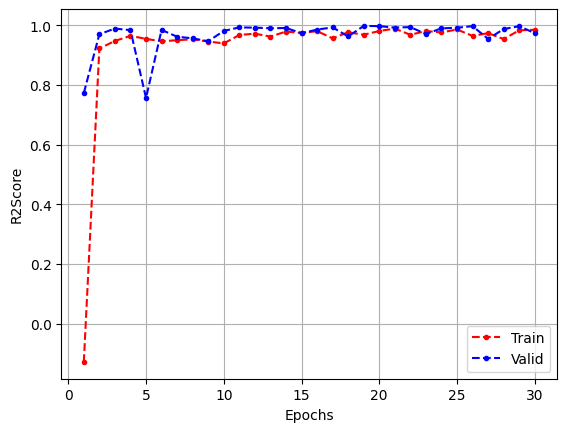

In [ ]:
learning_rate = 0.1
n_epochs = 30

model=nn.Sequential(
    nn.Linear(in_features=45, out_features=50),
    # nn.BatchNorm1d(50),
    nn.LeakyReLU(),
    nn.Linear(in_features=50, out_features=80),
    # nn.BatchNorm1d(80),
    nn.LeakyReLU(),
    nn.Linear(in_features=80, out_features=1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=learning_rate)
metric = torchmetrics.R2Score()

history = train(model, criterion, optimizer, metric, train_loader, valid_loader, n_epochs,clip_grad=True)
plot_history(history,n_epochs)

In [ ]:
model.eval()
metric.reset()

with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.975
